In [87]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.simulation import MarketSimulator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
# Initialisation du simulateur
sim = MarketSimulator(
    N=2000,          # Taille du réseau (50x50)
    T=2.5,        # Température (proche du point critique)
    J=1.0,         # Interaction
    h=0.0,         # Champ externe
    Delta_t=20000,  # Nombre de pas de temps
    P_0=100,       # Prix initial
    lambd=100      # Liquidité
)

# Lancement et export automatique en .parquet
sim.run()

# Chargement du fichier pour la visualisation
# Le nom doit correspondre à ton format de nommage automatique
filename = f"data/N2000_T2.5_J1.0_h0.0_t20000_P0100_l100.parquet"
df = pd.read_parquet(filename)

<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_10583/424077780.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel('ln Prix ($\ln P_t$)')


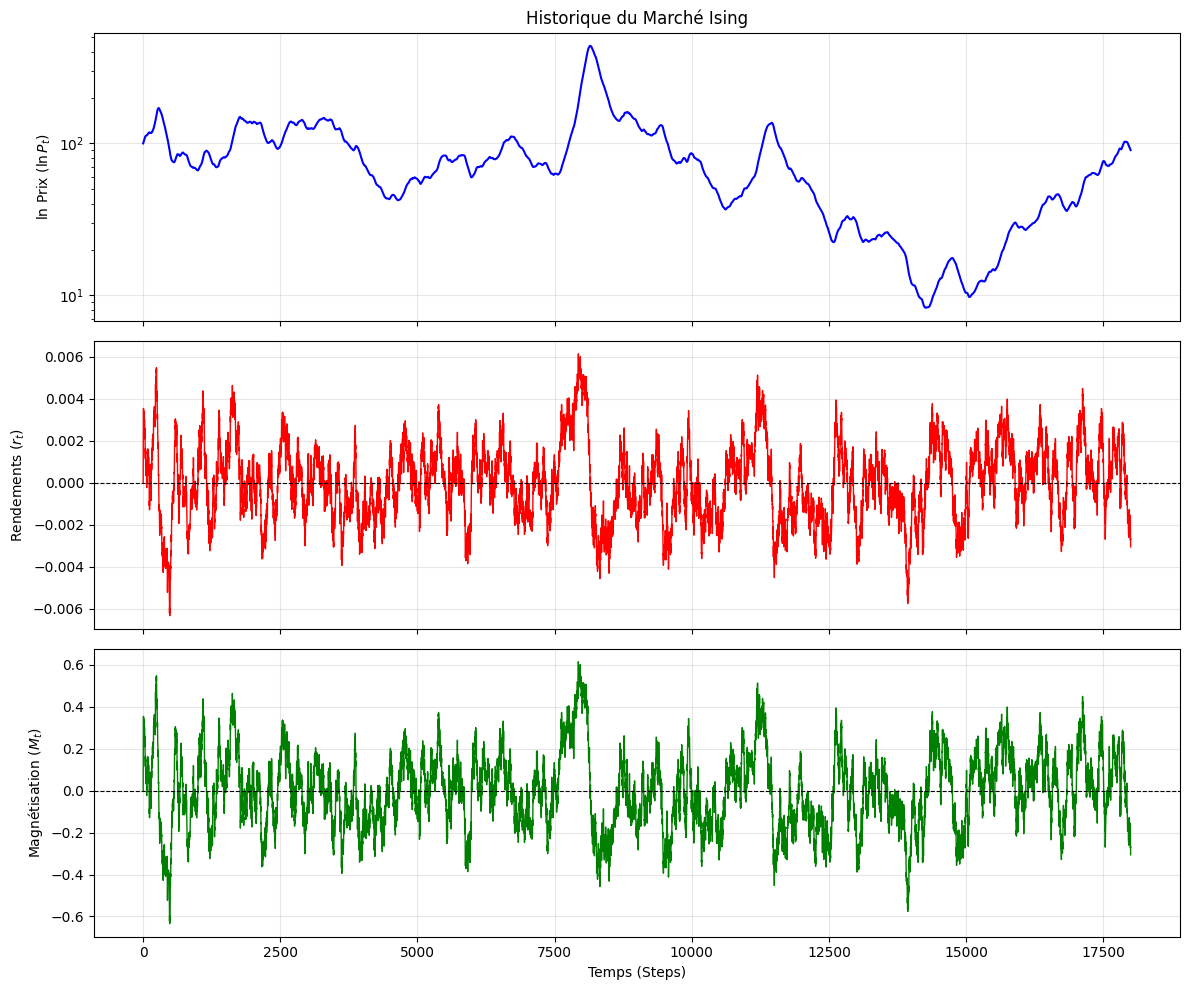

In [89]:
# Création de la figure avec 3 sous-graphiques (subplots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Graphique du Prix
ax1.semilogy(df['time'], df['P_history'], color='blue', lw=1.5)
ax1.set_ylabel('ln Prix ($\ln P_t$)')
ax1.set_title('Historique du Marché Ising')
ax1.grid(alpha=0.3)

# 2. Graphique des Rendements
ax2.plot(df['time'], df['r_history'], color='red', lw=1)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel('Rendements ($r_t$)')
ax2.grid(alpha=0.3)

# 3. Graphique de la Magnétisation
ax3.plot(df['time'], df['m_history'], color='green', lw=1)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_ylabel('Magnétisation ($M_t$)')
ax3.set_xlabel('Temps (Steps)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()